# MSM analysis: metastable states characterization, populations, probability fluxes

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from deeptime.plots import Network
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

from matplotlib.patches import Patch
from matplotlib import color_sequences
color_sequence = color_sequences['Paired']

n_macro = 6
timelag_macro = 1000 # validated with the CK test, see notebook step_3_msm_construction.ipynb

In [2]:
Q_timeseries = np.load("intermediate_outputs/Q_timeseries.npy")
macro_traj = np.load(f"intermediate_outputs/traj_pcca_{n_macro}_assignments.npy")
pca_traj = np.load("intermediate_outputs/mindists2_pca_5.npz")['arr_0']

In [3]:
average_Q_per_macrostate = []
for id in range(n_macro):
    frames = Q_timeseries[macro_traj == id]
    average_Q_per_macrostate.append(frames.mean())

# Renumber macrostates by average Q
sorted_indices = np.argsort(average_Q_per_macrostate)

dict = {old: new for new, old in enumerate(sorted_indices)}
macro_traj = np.array([dict[old] for old in macro_traj])

#### Compute statistics of native contacts Q per each macrostate

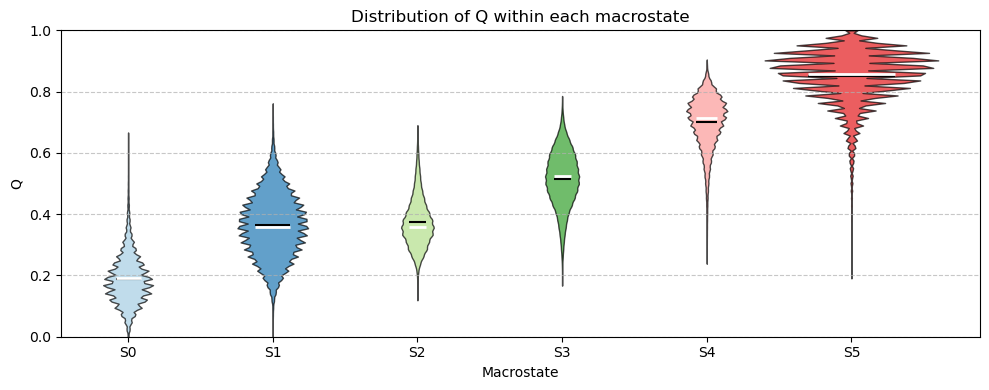

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

# Collect Q values for each macrostate
data = [
    Q_timeseries[macro_traj == i]
    for i in range(n_macro)
]
populations = np.bincount(macro_traj) / len(macro_traj)


vp = ax.violinplot(
    data,
    positions=np.arange(n_macro),
    widths=0.2 + populations / populations.max(),
    showmeans=True,
    showmedians=True,
    showextrema=False,
)

# Color violins
for body, color in zip(vp['bodies'], color_sequence[:n_macro]):
    body.set_facecolor(color)
    body.set_edgecolor('black')
    body.set_alpha(0.7)

# Style mean/median lines
vp['cmeans'].set_color('black')
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)

ax.set_xticks(np.arange(n_macro))
ax.set_xticklabels([f"S{i}" for i in range(n_macro)])
ax.set_xlabel("Macrostate")
ax.set_ylabel("Q")
ax.set_title("Distribution of Q within each macrostate")

ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

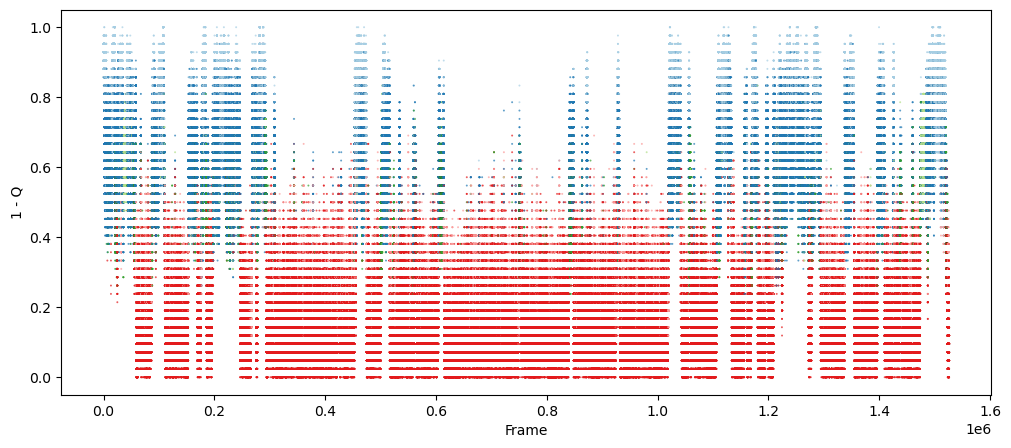

In [5]:
color_per_frame = np.array([color_sequence[id] for id in macro_traj])

stride = 1
nrows =  1
idx = np.arange(0, Q_timeseries.shape[0], stride)

frames_per_row = Q_timeseries.shape[0] // nrows


fig, ax = plt.subplots(nrows = nrows, ncols = 1, figsize=(12, 5 * nrows))

i = 0
idx = np.arange(i * frames_per_row, (i + 1) * frames_per_row, stride)

ax.scatter(
    idx,
    1 - Q_timeseries[idx],
    c=color_per_frame[idx],
    alpha=0.7,
    s=2,
    linewidths=0,
)
ax.set_xlabel("Frame")
ax.set_ylabel("1 - Q")
plt.show()

**Comment**: macrostates appear to caracterize the folding process, with $S8-S9$ corresponding to the native state and $S1-S2-S3$ to the most unfolded states. Now we need to go a little deeper. We aim to answer to these two main questions:

1. are these metastable states *structurally* distinct?
2. what are the dominant pathways connecting the folded and the unfolded state?

#### Build macrostate MSM

In [6]:
estimator_counts = TransitionCountEstimator(
    lagtime=int(timelag_macro),
    count_mode="sliding-effective"
)
macro_counts = estimator_counts.fit(macro_traj).fetch_model()

print("Weakly connected sets:", macro_counts.connected_sets(directed=False))
print("Strongly connected sets:", macro_counts.connected_sets(directed=True))


estimator_transition = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)
macro_msm = estimator_transition.fit(macro_counts).fetch_model()

Weakly connected sets: [array([0, 1, 2, 3, 4, 5])]
Strongly connected sets: [array([0, 1, 2, 3, 4, 5])]


Are these macrostates corresponding to local free energy minima? In other words: are these macrostates *metastable* ?

In [7]:
print("Self-transition probabilities:", macro_msm.transition_matrix.diagonal())

Self-transition probabilities: [0.53020692 0.61733039 0.48125402 0.23280895 0.11471912 0.89594444]


In [8]:
def plot_msm_network(
    T,
    ax=None,
    state_colors=None,
    pi=None,
    labels=None,
    top_k_per_state=2,
    min_prob=0.02,
    node_size_range=(800, 3500),
    edge_width_range=(1.0, 6.0),
    self_edges=False,
    seed=0,
):
    T = np.asarray(T, dtype=float)
    n = T.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: str(labels[i]) for i in range(n)}

    if state_colors is None:
        state_colors = ["lightgrey"] * n

    if pi is None:
        # left stationary distribution for row-stochastic T
        w, v = np.linalg.eig(T.T)
        idx = np.argmin(np.abs(w - 1))
        pi = np.real(v[:, idx])
        pi = np.abs(pi)
        pi = pi / pi.sum()

    # -----------------------------
    # Full graph for layout
    # -----------------------------
    G_full = nx.from_numpy_array(T, create_using=nx.DiGraph())

    pos = nx.spring_layout(
        G_full,
        weight="weight",
        k=5,
        seed=seed
    )

    # -----------------------------
    # Filter edges for plotting
    # -----------------------------
    G_plot = nx.DiGraph()
    G_plot.add_nodes_from(range(n))

    for i in range(n):
        probs = T[i].copy()

        if not self_edges:
            probs[i] = 0.0

        candidates = np.where(probs >= min_prob)[0]

        if len(candidates) > 0:
            strongest = candidates[np.argsort(probs[candidates])[-top_k_per_state:]]

            for j in strongest:
                G_plot.add_edge(i, j, weight=T[i, j])

    # -----------------------------
    # Node sizes
    # -----------------------------
    smin, smax = node_size_range
    if np.max(pi) > np.min(pi):
        node_sizes = smin + (pi - pi.min()) / (pi.max() - pi.min()) * (smax - smin)
    else:
        node_sizes = np.full(n, 0.5 * (smin + smax))

    # -----------------------------
    # Edge widths
    # -----------------------------
    edges = list(G_plot.edges())
    weights = np.array([G_plot[u][v]["weight"] for u, v in edges])

    if len(weights) > 0 and weights.max() > weights.min():
        wmin, wmax = edge_width_range
        edge_widths = wmin + (weights - weights.min()) / (weights.max() - weights.min()) * (wmax - wmin)
    elif len(weights) > 0:
        edge_widths = np.full(len(weights), np.mean(edge_width_range))
    else:
        edge_widths = []

    # -----------------------------
    # Draw
    # -----------------------------
    nx.draw_networkx_nodes(
        G_plot,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=state_colors,
        edgecolors="black",
        linewidths=1.5,
        alpha = 0.6
    )

    nx.draw_networkx_labels(
        G_plot,
        pos,
        labels=labels,
        ax=ax,
        font_size=11,
        font_weight="bold"
    )

    nx.draw_networkx_edges(
        G_plot,
        pos,
        ax=ax,
        edgelist=edges,
        width=edge_widths,
        arrows=True,
        arrowsize=15,
        arrowstyle="-|>",
        min_target_margin=25,
        min_source_margin=20,
        connectionstyle="arc3,rad=0.15",
        alpha=0.75
    )

    ax.set_title("Dominant macrostate transitions")
    ax.axis("off")

    return ax, G_plot, pos

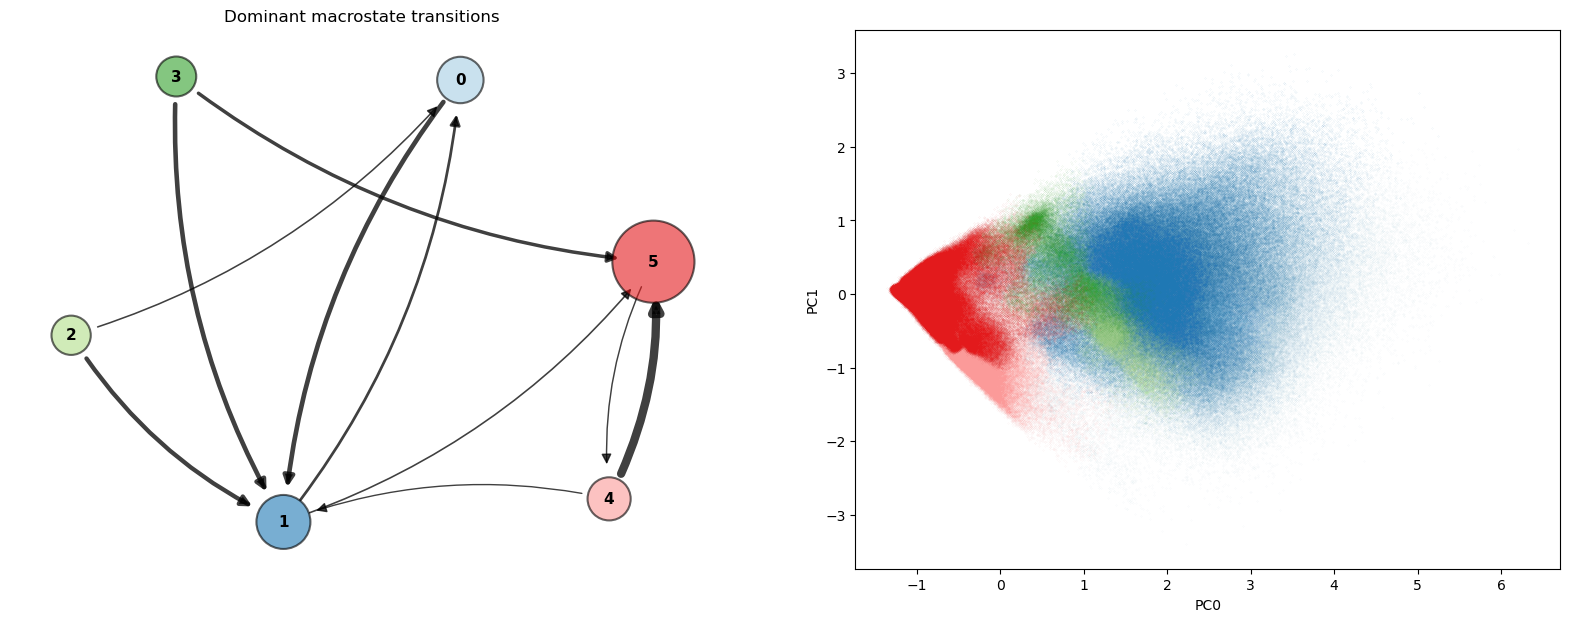

In [9]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 7))

#############################
# graph transition matrix

ax = axs[0]
ax, G_plot, pos = plot_msm_network(
    macro_msm.transition_matrix,
    ax=ax,
    state_colors=color_sequence[:n_macro],
    top_k_per_state=2,
    min_prob=0.03,
    self_edges=False,
    seed=0
)

#############################
# pca plot
ax = axs[1]
for id in range(n_macro):
    frames = pca_traj[macro_traj == id]
    ax.scatter(
        frames[:, 0],
        frames[:, 1],
        color=color_sequence[id],
        alpha = 0.3,
        s=0.01,
    )
ax.set_xlabel(f"PC0")
ax.set_ylabel(f"PC1")

plt.show()

---
## Structural investigation

#### Fraction of native contacts *divided by MOSAIC clusters*

In [13]:
subsets = ['MoSAIC1', 'MoSAIC2', 'MoSAIC3', 'MoSAIC4', 'MoSAIC5', 'MoSAIC6', 'MoSAIC7', 'MoSAIC8']
filenames = [f"intermediate_outputs/Q_timeseries_{subset}.npy" for subset in subsets]

MoSAIC_Q_timeseries = [np.load(filename) for filename in filenames]
MoSAIC_1minusQ_timeseries = [1 - Q for Q in MoSAIC_Q_timeseries]

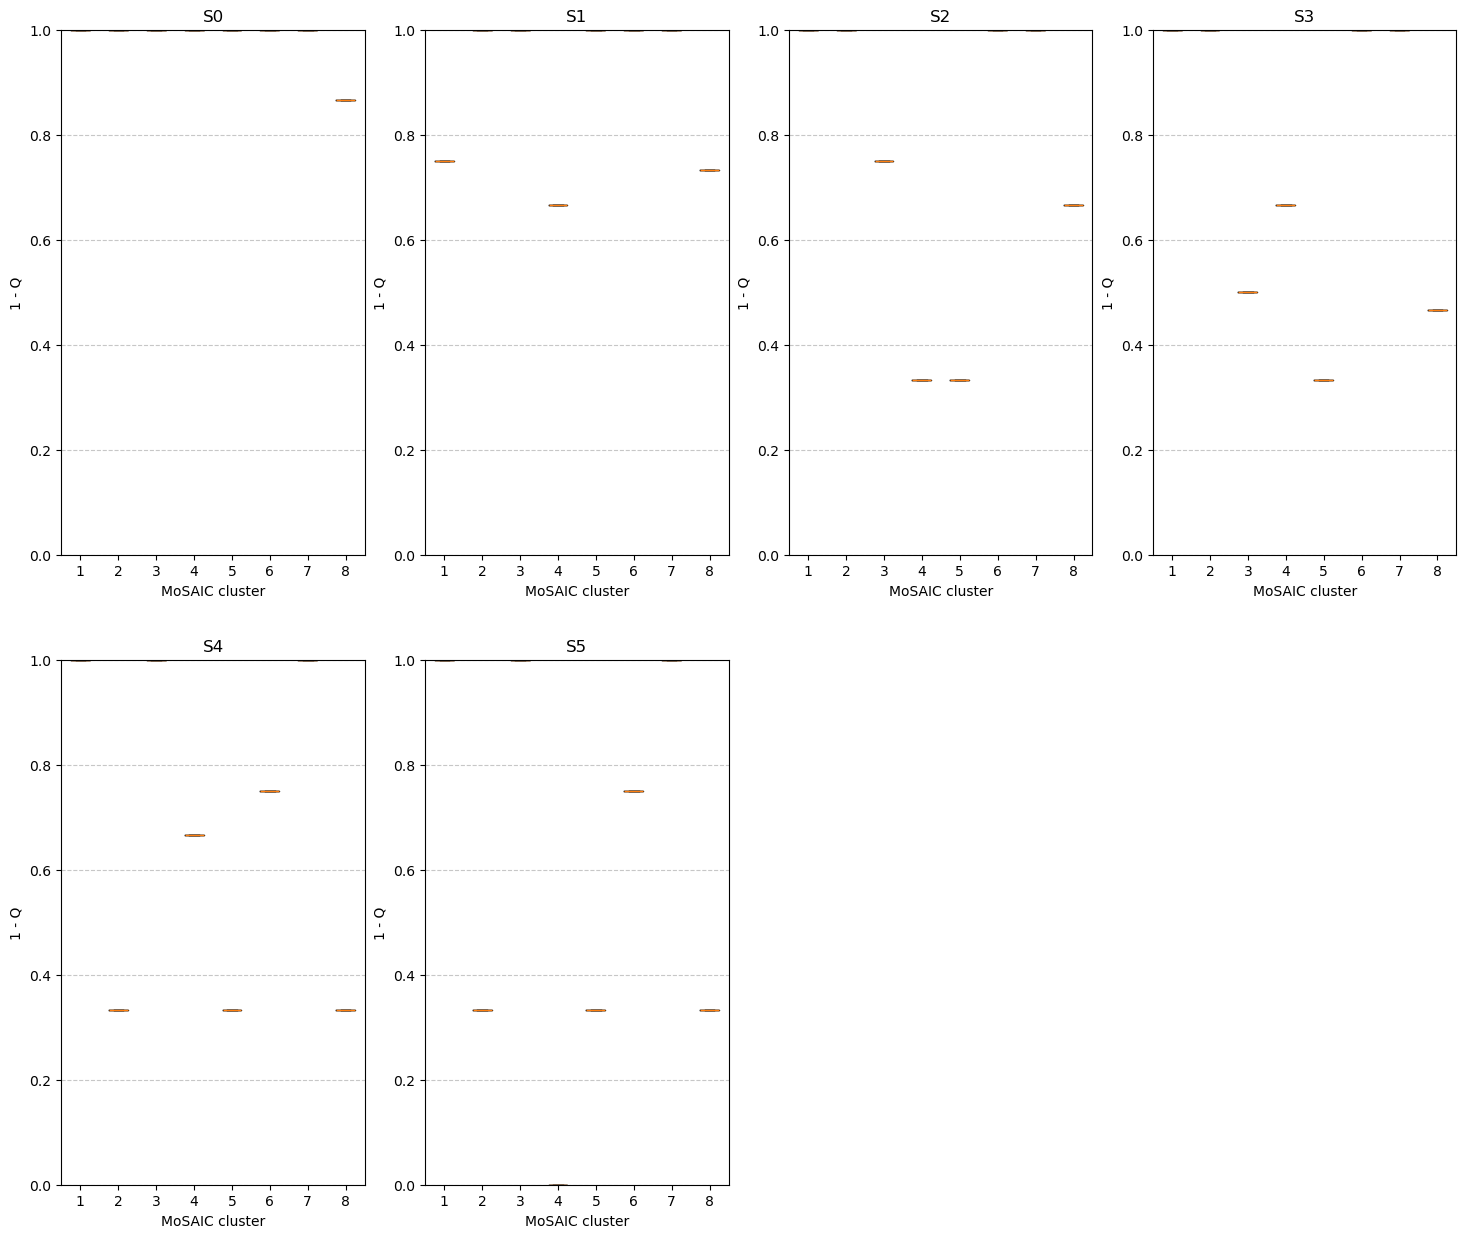

In [ ]:
nrows = (n_macro // 4) + 1

fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(18, 15))
axs = axs.flatten()

for ax in axs[n_macro:]:
    ax.axis('off')

for i, state in enumerate(np.arange(0, n_macro)):
    ax = axs[i]
    ax.set_title(f"S{state}")

    frame_indices = np.argwhere(macro_traj == state)[0]
    # Make boxplot of Q values for each cluster
    Q_subsets = [
        cluster_timeseries[frame_indices]
        for cluster_timeseries in MoSAIC_1minusQ_timeseries
    ]
    ax.boxplot(Q_subsets, tick_labels=[f"{j+1}" for j in range(len(Q_subsets))])
    ax.set_xlabel("MoSAIC cluster")
    ax.set_ylabel("1 - Q")
    # make same y-axis limits for all subplots
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)